In [1]:
import requests
from bs4 import BeautifulSoup
import networkx as nx
import time
import pickle
import os

In [2]:
SEP_BASE = "https://plato.stanford.edu"

def get_all_entries():
    """Get all SEP entry URLs from the table of contents."""
    r = requests.get(f"{SEP_BASE}/contents.html")
    soup = BeautifulSoup(r.text, 'html.parser')
    entries = {}
    for a in soup.select('div#content a[href]'):
        href = a['href']
        if href.startswith('entries/'):
            slug = href.rstrip('/').split('/')[-1]
            entries[slug] = a.text.strip()
    return entries  # {slug: title}

def get_entry_links(slug):
    """Get all internal SEP links from one entry."""
    url = f"{SEP_BASE}/entries/{slug}/"
    try:
        r = requests.get(url, timeout=10)
        soup = BeautifulSoup(r.text, 'html.parser')
        links = set()
        for a in soup.select('a[href]'):
            href = a['href']
            # Match relative links to other entries
            if '../../entries/' in href or href.startswith('../'):
                target = href.strip('/').split('/')[-1].split('#')[0]
                if target and target != slug:
                    links.add(target)
        return links
    except Exception:
        return set()

def build_sep_graph(entries, cache='sep_graph.pkl'):
    if os.path.exists(cache):
        with open(cache, 'rb') as f:
            return pickle.load(f)
    
    G = nx.DiGraph()
    for slug, title in entries.items():
        G.add_node(slug, title=title)
    
    for i, (slug, title) in enumerate(entries.items()):
        links = get_entry_links(slug)
        for target in links:
            if target in entries:
                G.add_edge(slug, target)
        time.sleep(0.8)  # be polite to the SEP server
        if i % 50 == 0:
            print(f"  {i}/{len(entries)} — {title}")
    
    with open(cache, 'wb') as f:
        pickle.dump(G, f)
    return G

entries = get_all_entries()
G = build_sep_graph(entries)
print(f"Nodes: {G.number_of_nodes()}, Edges: {G.number_of_edges()}")

  0/1861 — abduction
  50/1861 — aesthetics
  100/1861 — analogy: medieval theories of
  150/1861 — David
  200/1861 — authenticity
  250/1861 — developmental biology
  300/1861 — Cambridge Platonists
  350/1861 — Chinese and Western
  400/1861 — cognitivism vs. non-cognitivism, moral
  450/1861 — consequentialism: rule
  500/1861 — Heidegger, Martin
  550/1861 — evolution and development
  600/1861 — double effect, doctrine of
  650/1861 — epistemic paradoxes
  700/1861 — the legal concept of
  750/1861 — philosophy of language
  800/1861 — free rider problem
  850/1861 — moral arguments
  900/1861 — moral and political philosophy
  950/1861 — impartiality
  1000/1861 — inverted
  1050/1861 — Kepler, Johannes
  1100/1861 — ethics
  1150/1861 — independence friendly
  1200/1861 — Madhyamaka
  1250/1861 — literary forms of
  1300/1861 — first-order
  1350/1861 — in the Renaissance
  1400/1861 — Origen
  1450/1861 — phylogenetic inference
  1500/1861 — Principia Mathematica
  1550/1861 —

In [5]:
import pandas as pd
import numpy as np

# Work on undirected graph for betweenness
# (standard practice: we care about conceptual proximity, not link direction)
G_u = G.to_undirected()

# Keep only the largest connected component
lcc_nodes = max(nx.connected_components(G_u), key=len)
G_lcc = G_u.subgraph(lcc_nodes).copy()
print(f"LCC: {G_lcc.number_of_nodes()} nodes, {G_lcc.number_of_edges()} edges")

# Exact betweenness — feasible at this scale
print("Computing betweenness (this takes 2–5 min)...")
bc = nx.betweenness_centrality(G_lcc, normalized=True)
cc = nx.closeness_centrality(G_lcc)
dc = nx.degree_centrality(G_lcc)
pr = nx.pagerank(G, alpha=0.85)  # use directed graph for PageRank

# Build results DataFrame with human-readable titles
df = pd.DataFrame({
    'slug':        list(bc.keys()),
    'title':       [entries.get(n, n) for n in bc.keys()],
    'betweenness': list(bc.values()),
    'closeness':   [cc[n] for n in bc],
    'degree':      [dc[n] for n in bc],
    'pagerank':    [pr.get(n, 0) for n in bc],
})

# The bridge ratio: high betweenness relative to degree
df['bridge_ratio'] = df['betweenness'] / (df['degree'] + 1e-9)

# Three ranked lists — each tells a different story
print("\nTop 15 by betweenness (structurally central):")
print(df.nlargest(15, 'betweenness')[['title','betweenness','degree']].to_string())

print("\nTop 15 by bridge ratio (hidden bridges):")
print(df.nlargest(15, 'bridge_ratio')[['title','betweenness','degree','bridge_ratio']].to_string())

print("\nTop 15 by PageRank (prestige-weighted centrality):")
print(df.nlargest(15, 'pagerank')[['title','pagerank','degree']].to_string())

LCC: 1861 nodes, 18892 edges
Computing betweenness (this takes 2–5 min)...

Top 15 by betweenness (structurally central):
                    title  betweenness    degree
148             Aristotle     0.038399  0.071505
1032       Kant, Immanuel     0.032647  0.069355
124       Aquinas, Thomas     0.029568  0.062366
1249  medieval philosophy     0.029329  0.085484
1458                Plato     0.018603  0.048925
914           Hume, David     0.016039  0.046774
531       Descartes, René     0.015153  0.050538
449      consequentialism     0.014785  0.045161
1656    science: unity of     0.012936  0.034409
1659    scientific method     0.012890  0.036022
1786              trinity     0.012770  0.041935
194            properties     0.012758  0.046237
801             free will     0.012738  0.038172
110     animal: cognition     0.011994  0.027419
685        ethics: virtue     0.011978  0.032258

Top 15 by bridge ratio (hidden bridges):
                           title  betweenness    deg

In [6]:
# Find the disagreements
top_bc  = set(df.nlargest(30, 'betweenness')['slug'])
top_pr  = set(df.nlargest(30, 'pagerank')['slug'])
top_br  = set(df.nlargest(30, 'bridge_ratio')['slug'])

# High betweenness but NOT high PageRank = underappreciated bridges
underappreciated = top_bc - top_pr
print("Structurally critical but not famous:")
print(df[df['slug'].isin(underappreciated)][['title','betweenness','pagerank']])

# High PageRank but NOT high betweenness = prestige hubs
prestige_hubs = top_pr - top_bc
print("\nFamous but not structurally critical:")
print(df[df['slug'].isin(prestige_hubs)][['title','betweenness','pagerank']])

Structurally critical but not famous:
                               title  betweenness  pagerank
110                animal: cognition     0.011994  0.000508
144       argument and argumentation     0.010499  0.000220
630                          emotion     0.008363  0.001391
736              feminist philosophy     0.009158  0.000497
884   Hegel, Georg Wilhelm Friedrich     0.009884  0.002311
932                         idealism     0.010941  0.001163
945                      imagination     0.009092  0.000549
969                         infinity     0.009792  0.000396
1114                    Lewis, David     0.009071  0.001070
1249             medieval philosophy     0.029329  0.001697
1271                       mereology     0.008877  0.001804
1280                     metaphysics     0.011001  0.001574
1395                 social ontology     0.008451  0.000271
1656               science: unity of     0.012936  0.000631
1659               scientific method     0.012890  0.000587
17

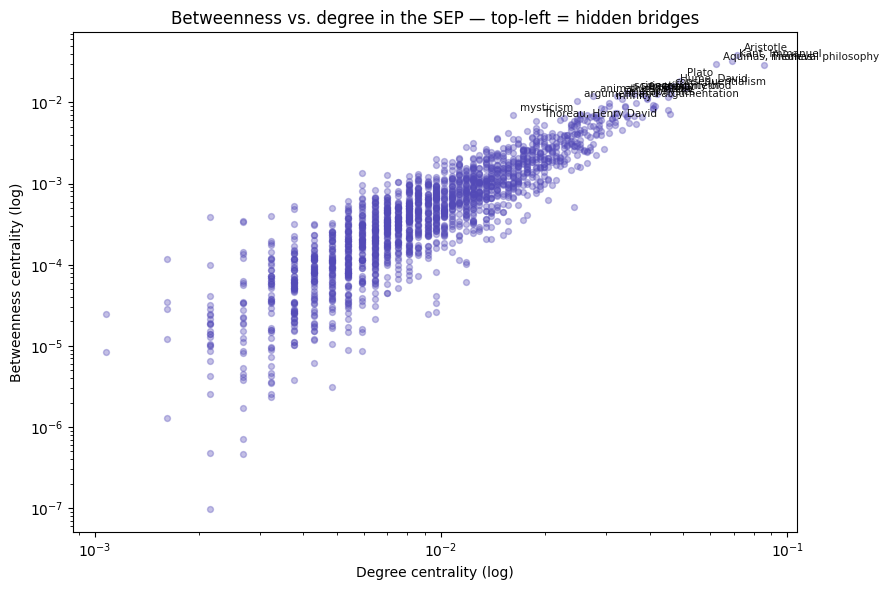

In [8]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(df['degree'], df['betweenness'],
           alpha=0.35, s=18, color='#534AB7')

# Annotate top bridge-ratio entries (not just top betweenness)
to_label = df.nlargest(18, 'bridge_ratio')
for _, row in to_label.iterrows():
    ax.annotate(row['title'][:28],
                (row['degree'], row['betweenness']),
                fontsize=7.5, alpha=0.9,
                xytext=(5, 3), textcoords='offset points')

ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('Degree centrality (log)')
ax.set_ylabel('Betweenness centrality (log)')
ax.set_title('Betweenness vs. degree in the SEP — top-left = hidden bridges')
plt.tight_layout()

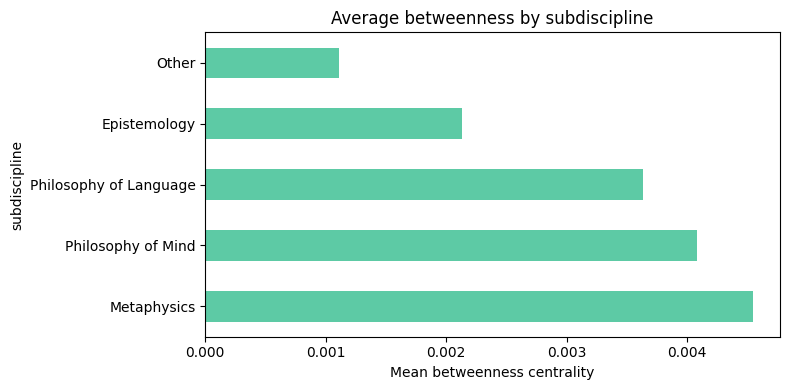

In [10]:
import seaborn as sns

# Manually assign subdisciplines from SEP categories
# (or use entry title keywords as a proxy)
subdiscipline_map = {
    'causation': 'Metaphysics',
    'truth': 'Philosophy of Language',
    'consciousness': 'Philosophy of Mind',
    'knowledge-analysis': 'Epistemology',
    'modality-epistemology': 'Epistemology',
    'possible-worlds': 'Metaphysics',
    # ... extend for top entries
}
df['subdiscipline'] = df['slug'].map(subdiscipline_map).fillna('Other')

avg_bc = (df.groupby('subdiscipline')['betweenness']
            .mean()
            .sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(8, 4))
avg_bc.plot(kind='barh', ax=ax, color='#5DCAA5')
ax.set_xlabel('Mean betweenness centrality')
ax.set_title('Average betweenness by subdiscipline')
plt.tight_layout()

In [12]:
from pyvis.network import Network

# Color nodes by subdiscipline
color_map = {
    'Metaphysics':             '#7F77DD',
    'Epistemology':            '#1D9E75',
    'Philosophy of Mind':      '#D85A30',
    'Philosophy of Language':  '#378ADD',
    'Ethics':                  '#EF9F27',
    'Logic':                   '#888780',
    'Other':                   '#B4B2A9',
}

# Show top 300 nodes by betweenness
top = df.nlargest(300, 'betweenness')['slug'].tolist()
G_vis = G_lcc.subgraph(top)

net = Network(height='680px', notebook=True)
for node in G_vis.nodes():
    row = df[df['slug'] == node].iloc[0]
    sub = subdiscipline_map.get(node, 'Other')
    net.add_node(node,
                 label=row['title'][:30],
                 size=row['betweenness'] * 4000 + 6,
                 color=color_map.get(sub, '#B4B2A9'),
                 title=f"{row['title']}<br>Betweenness: {row['betweenness']:.4f}<br>Bridge ratio: {row['bridge_ratio']:.2f}")
for u, v in G_vis.edges():
    net.add_edge(u, v, width=0.4, color='#D3D1C7')

net.show('sep_bridges.html')

sep_bridges.html
